In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/models").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

print(f"Using device: {device}")

Using device: cpu


In [2]:
def generate_change_detection_trials(
    n_trials,
    delay_steps=4,
    change_threshold=0.15,
    change_probability=0.5,
    stimulus_noise=0.00,
    seed=None
):
    """
    Generate trials for an abstract delayed change-detection task.

    Returns
    -------
    x : torch.FloatTensor
        Shape: (n_trials, sequence_length, 3)
        Features: [stimulus_value, stimulus_present, response_cue].

    y : torch.FloatTensor
        Shape: (n_trials,)
        Binary label: 0 = same, 1 = change.

    metadata : pandas.DataFrame
        One row per trial, retained for behavioral analyses.
    """
    rng = np.random.default_rng(seed)

    sequence_length = delay_steps + 3
    x = np.zeros((n_trials, sequence_length, 3), dtype=np.float32)
    y = np.zeros(n_trials, dtype=np.float32)

    rows = []

    for trial in range(n_trials):
        reference = rng.uniform(0.0, 1.0)
        is_change = rng.random() < change_probability

        if is_change:
            direction = rng.choice([-1.0, 1.0])
            minimum_difference = change_threshold
            maximum_difference = max(reference, 1.0 - reference)

            if maximum_difference < minimum_difference:
                probe = 1.0 - reference
            else:
                difference = rng.uniform(minimum_difference, maximum_difference)
                probe = np.clip(reference + direction * difference, 0.0, 1.0)

                if abs(probe - reference) < change_threshold:
                    probe = np.clip(reference - direction * difference, 0.0, 1.0)
        else:
            probe = reference

        reference_observed = np.clip(
            reference + rng.normal(0, stimulus_noise), 0.0, 1.0
        )
        probe_observed = np.clip(
            probe + rng.normal(0, stimulus_noise), 0.0, 1.0
        )

        reference_time = 0
        probe_time = delay_steps + 1
        response_time = delay_steps + 2

        x[trial, reference_time] = [reference_observed, 1.0, 0.0]
        x[trial, probe_time] = [probe_observed, 1.0, 0.0]
        x[trial, response_time] = [0.0, 0.0, 1.0]

        y[trial] = float(is_change)

        rows.append({
            "trial": trial,
            "reference": reference,
            "probe": probe,
            "physical_change_magnitude": abs(probe - reference),
            "is_change": int(is_change),
            "delay_steps": delay_steps
        })

    return (
        torch.tensor(x, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        pd.DataFrame(rows)
    )

In [3]:
x_demo, y_demo, demo_metadata = generate_change_detection_trials(
    n_trials=5,
    delay_steps=4,
    change_threshold=0.15,
    stimulus_noise=0.0,
    seed=42
)

feature_names = ["stimulus_value", "stimulus_present", "response_cue"]

for trial_number in range(5):
    trial_table = pd.DataFrame(
        x_demo[trial_number].numpy(),
        columns=feature_names
    )
    print(f"\nTrial {trial_number}")
    print(demo_metadata.iloc[trial_number])
    print(trial_table)
    print(f"Target: {'CHANGE' if y_demo[trial_number].item() == 1 else 'SAME'}")


Trial 0
trial                        0.000000
reference                    0.773956
probe                        0.188829
physical_change_magnitude    0.585127
is_change                    1.000000
delay_steps                  4.000000
Name: 0, dtype: float64
   stimulus_value  stimulus_present  response_cue
0        0.773956               1.0           0.0
1        0.000000               0.0           0.0
2        0.000000               0.0           0.0
3        0.000000               0.0           0.0
4        0.000000               0.0           0.0
5        0.188829               1.0           0.0
6        0.000000               0.0           1.0
Target: CHANGE

Trial 1
trial                        1.00000
reference                    0.76114
probe                        0.76114
physical_change_magnitude    0.00000
is_change                    0.00000
delay_steps                  4.00000
Name: 1, dtype: float64
   stimulus_value  stimulus_present  response_cue
0         0.76114  

In [4]:
task_parameters = {
    "delay_steps": 4,
    "change_threshold": 0.15,
    "change_probability": 0.5,
    "stimulus_noise": 0.00
}

x_train, y_train, meta_train = generate_change_detection_trials(
    n_trials=20_000,
    seed=1,
    **task_parameters
)

x_val, y_val, meta_val = generate_change_detection_trials(
    n_trials=4_000,
    seed=2,
    **task_parameters
)

x_test, y_test, meta_test = generate_change_detection_trials(
    n_trials=4_000,
    seed=3,
    **task_parameters
)

batch_size = 128

train_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(x_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(x_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

In [5]:
class ChangeDetectionGRU(nn.Module):
    def __init__(self, input_size=3, hidden_size=32):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.readout = nn.Linear(hidden_size, 1)

    def forward(self, x, return_hidden_trajectory=False):
        """
        Parameters
        ----------
        x : torch.Tensor
            Shape: (batch, time, 3).

        return_hidden_trajectory : bool
            If True, also return the hidden state at every time point.

        Returns
        -------
        logits : torch.Tensor
            Shape: (batch,). Higher values mean stronger evidence for change.

        hidden_trajectory : torch.Tensor, optional
            Shape: (batch, time, hidden_size).
        """
        hidden_trajectory, final_hidden = self.gru(x)

        final_state = final_hidden[-1]
        logits = self.readout(final_state).squeeze(-1)

        if return_hidden_trajectory:
            return logits, hidden_trajectory

        return logits

In [6]:
def run_epoch(model, data_loader, loss_function, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(x_batch)
            loss = loss_function(logits, y_batch)

            if is_training:
                loss.backward()
                optimizer.step()

        predicted_change = (torch.sigmoid(logits) >= 0.5).float()

        total_loss += loss.item() * y_batch.size(0)
        total_correct += (predicted_change == y_batch).sum().item()
        total_examples += y_batch.size(0)

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples
    }

In [7]:
model = ChangeDetectionGRU(
    input_size=3,
    hidden_size=32
).to(device)

loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

n_epochs = 40
history = []

best_validation_loss = np.inf

for epoch in range(1, n_epochs + 1):
    train_metrics = run_epoch(
        model=model,
        data_loader=train_loader,
        loss_function=loss_function,
        optimizer=optimizer
    )

    validation_metrics = run_epoch(
        model=model,
        data_loader=val_loader,
        loss_function=loss_function
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"]
    }

    history.append(epoch_record)

    if validation_metrics["loss"] < best_validation_loss:
        best_validation_loss = validation_metrics["loss"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "task_parameters": task_parameters,
                "hidden_size": 32,
                "epoch": epoch,
                "validation_loss": best_validation_loss
            },
            "outputs/models/best_gru_change_detection.pt"
        )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"train loss={train_metrics['loss']:.4f}, "
            f"train accuracy={train_metrics['accuracy']:.3f} | "
            f"val loss={validation_metrics['loss']:.4f}, "
            f"val accuracy={validation_metrics['accuracy']:.3f}"
        )

history_df = pd.DataFrame(history)
history_df.to_csv("outputs/tables/training_history.csv", index=False)

Epoch 01 | train loss=0.6936, train accuracy=0.494 | val loss=0.6932, val accuracy=0.504
Epoch 05 | train loss=0.6933, train accuracy=0.503 | val loss=0.6930, val accuracy=0.504
Epoch 10 | train loss=0.1314, train accuracy=0.974 | val loss=0.0380, val accuracy=0.996
Epoch 15 | train loss=0.0024, train accuracy=1.000 | val loss=0.0019, val accuracy=1.000
Epoch 20 | train loss=0.0008, train accuracy=1.000 | val loss=0.0007, val accuracy=1.000
Epoch 25 | train loss=0.0004, train accuracy=1.000 | val loss=0.0003, val accuracy=1.000
Epoch 30 | train loss=0.0002, train accuracy=1.000 | val loss=0.0002, val accuracy=1.000
Epoch 35 | train loss=0.0002, train accuracy=1.000 | val loss=0.0002, val accuracy=1.000
Epoch 40 | train loss=0.0001, train accuracy=1.000 | val loss=0.0001, val accuracy=1.000


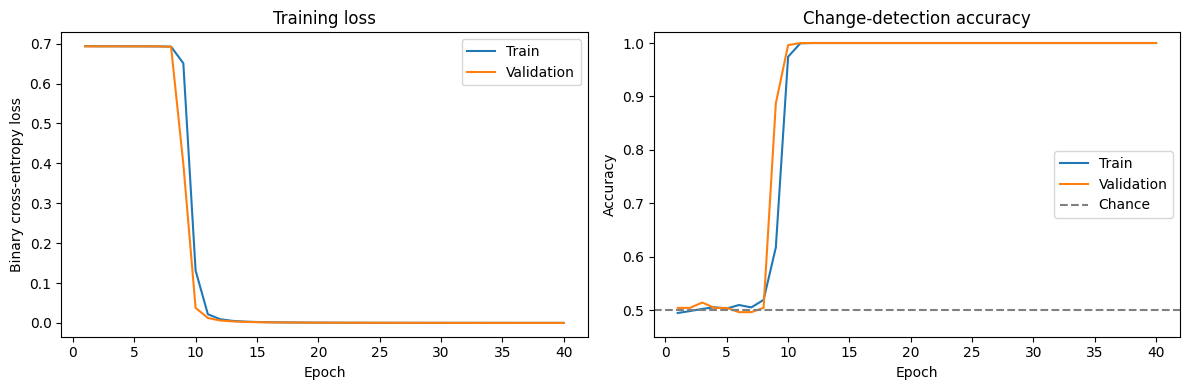

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["validation_loss"], label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy loss")
axes[0].set_title("Training loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train")
axes[1].plot(history_df["epoch"], history_df["validation_accuracy"], label="Validation")
axes[1].axhline(0.5, color="gray", linestyle="--", label="Chance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.45, 1.02)
axes[1].set_title("Change-detection accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    "outputs/figures/training_curves.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [9]:
checkpoint = torch.load(
    "outputs/models/best_gru_change_detection.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_metrics = run_epoch(
    model=model,
    data_loader=test_loader,
    loss_function=loss_function
)

print(
    f"Best epoch: {checkpoint['epoch']}\n"
    f"Test loss: {test_metrics['loss']:.4f}\n"
    f"Test accuracy: {test_metrics['accuracy']:.3f}"
)

Best epoch: 40
Test loss: 0.0001
Test accuracy: 1.000


In [11]:
@torch.no_grad()
def predict_trials(model, x):
    model.eval()

    logits = model(x.to(device))
    probabilities = torch.sigmoid(logits).cpu().numpy()

    return probabilities

test_probabilities = predict_trials(model, x_test)

model_test_table = meta_test.copy()
model_test_table["rnn_change_probability"] = test_probabilities
model_test_table["rnn_response_change"] = (
    model_test_table["rnn_change_probability"] >= 0.5
).astype(int)

model_test_table["correct"] = (
    model_test_table["rnn_response_change"] ==
    model_test_table["is_change"]
).astype(int)

model_test_table.to_csv(
    "outputs/tables/rnn_test_trial_table.csv",
    index=False
)

model_test_table.head()

,trial,reference,probe,physical_change_magnitude,is_change,delay_steps,rnn_change_probability,rnn_response_change,correct
0,0,0.085649,0.680625,0.594976,1,4,0.999999,1,1
1,1,0.479051,0.901542,0.422490,1,4,0.999999,1,1
2,2,0.516740,0.937335,0.420595,1,4,0.999999,1,1
3,3,0.648547,0.648547,0.000000,0,4,0.000082,0,1
4,4,0.973460,0.564905,0.408555,1,4,0.999999,1,1


In [12]:
x_test_reference_removed = x_test.clone()

reference_time = 0

x_test_reference_removed[:, reference_time, 0] = 0.0
x_test_reference_removed[:, reference_time, 1] = 0.0

ablation_probabilities = predict_trials(model, x_test_reference_removed)

ablation_predictions = (ablation_probabilities >= 0.5).astype(int)
ablation_accuracy = (
    ablation_predictions == y_test.numpy().astype(int)
).mean()

print(f"Normal test accuracy: {test_metrics['accuracy']:.3f}")
print(f"Reference-removed accuracy: {ablation_accuracy:.3f}")

Normal test accuracy: 1.000
Reference-removed accuracy: 0.500


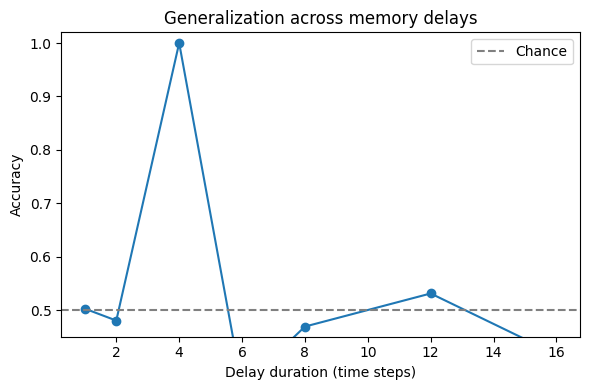

In [13]:
delay_results = []

for delay_steps in [1, 2, 4, 6, 8, 12, 16]:
    x_delay, y_delay, meta_delay = generate_change_detection_trials(
        n_trials=4_000,
        delay_steps=delay_steps,
        change_threshold=0.15,
        change_probability=0.5,
        stimulus_noise=0.0,
        seed=100 + delay_steps
    )

    probabilities = predict_trials(model, x_delay)
    predictions = (probabilities >= 0.5).astype(int)

    accuracy = (
        predictions == y_delay.numpy().astype(int)
    ).mean()

    delay_results.append({
        "delay_steps": delay_steps,
        "accuracy": accuracy
    })

delay_results_df = pd.DataFrame(delay_results)
delay_results_df.to_csv(
    "outputs/tables/delay_generalization.csv",
    index=False
)

plt.figure(figsize=(6, 4))
plt.plot(
    delay_results_df["delay_steps"],
    delay_results_df["accuracy"],
    marker="o"
)
plt.axhline(0.5, color="gray", linestyle="--", label="Chance")
plt.xlabel("Delay duration (time steps)")
plt.ylabel("Accuracy")
plt.ylim(0.45, 1.02)
plt.title("Generalization across memory delays")
plt.legend()
plt.tight_layout()
plt.savefig(
    "outputs/figures/delay_generalization.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [14]:
def generate_variable_delay_trials(
    n_trials,
    min_delay=1,
    max_delay=8,
    change_threshold=0.15,
    change_probability=0.5,
    stimulus_noise=0.0,
    seed=None
):
    rng = np.random.default_rng(seed)

    all_x = []
    all_y = []
    all_metadata = []

    for trial in range(n_trials):
        delay = int(rng.integers(min_delay, max_delay + 1))

        x_trial, y_trial, metadata_trial = generate_change_detection_trials(
            n_trials=1,
            delay_steps=delay,
            change_threshold=change_threshold,
            change_probability=change_probability,
            stimulus_noise=stimulus_noise,
            seed=int(rng.integers(0, 1_000_000_000))
        )

        all_x.append(x_trial)
        all_y.append(y_trial)
        all_metadata.append(metadata_trial)

    max_sequence_length = max(x.shape[1] for x in all_x)

    padded_x = torch.zeros(
        (n_trials, max_sequence_length, 3),
        dtype=torch.float32
    )

    for i, x_trial in enumerate(all_x):
        padded_x[i, :x_trial.shape[1], :] = x_trial[0]

    y = torch.cat(all_y)
    metadata = pd.concat(all_metadata, ignore_index=True)

    return padded_x, y, metadata

In [15]:
@torch.no_grad()
def get_hidden_trajectories(model, x):
    model.eval()

    logits, hidden_trajectory = model(
        x.to(device),
        return_hidden_trajectory=True
    )

    probabilities = torch.sigmoid(logits).cpu().numpy()

    return (
        probabilities,
        hidden_trajectory.cpu().numpy()
    )

example_x = x_test[:20]
example_probabilities, example_hidden = get_hidden_trajectories(
    model,
    example_x
)

print("Hidden trajectory shape:", example_hidden.shape)

Hidden trajectory shape: (20, 7, 32)


In [16]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x_memory, y_memory, meta_memory = generate_change_detection_trials(
    n_trials=5_000,
    delay_steps=4,
    change_threshold=0.15,
    seed=99
)

_, hidden_memory = get_hidden_trajectories(model, x_memory)

delay_time_index = 3
hidden_during_delay = hidden_memory[:, delay_time_index, :]
reference_values = meta_memory["reference"].to_numpy()

x_decoder_train, x_decoder_test, y_decoder_train, y_decoder_test = train_test_split(
    hidden_during_delay,
    reference_values,
    test_size=0.25,
    random_state=SEED
)

decoder = Ridge(alpha=1.0)
decoder.fit(x_decoder_train, y_decoder_train)

decoded_reference = decoder.predict(x_decoder_test)
memory_r2 = r2_score(y_decoder_test, decoded_reference)

print(f"Reference decoding R² during delay: {memory_r2:.3f}")

Reference decoding R² during delay: 1.000


In [17]:
def generate_variable_delay_trials(
    n_trials,
    min_delay=1,
    max_delay=8,
    change_threshold=0.15,
    change_probability=0.5,
    stimulus_noise=0.00,
    seed=None
):
    """
    Create variable-delay delayed change-detection trials.

    Input features:
        0 = stimulus value
        1 = stimulus-present indicator
        2 = response-cue indicator

    Returns:
        x:             (trials, max_time, 3)
        y:             (trials,)
        response_mask: (trials, max_time), True only at response cue
        metadata:      one row per trial
    """
    rng = np.random.default_rng(seed)

    max_time = max_delay + 3

    x = np.zeros((n_trials, max_time, 3), dtype=np.float32)
    y = np.zeros(n_trials, dtype=np.float32)
    response_mask = np.zeros((n_trials, max_time), dtype=bool)

    rows = []

    for trial in range(n_trials):
        delay_steps = int(rng.integers(min_delay, max_delay + 1))

        reference = rng.uniform(0.0, 1.0)
        is_change = rng.random() < change_probability

        if is_change:
            while True:
                probe = rng.uniform(0.0, 1.0)

                if abs(probe - reference) >= change_threshold:
                    break
        else:
            probe = reference

        reference_observed = np.clip(
            reference + rng.normal(0, stimulus_noise),
            0.0,
            1.0
        )

        probe_observed = np.clip(
            probe + rng.normal(0, stimulus_noise),
            0.0,
            1.0
        )

        reference_time = 0
        probe_time = delay_steps + 1
        response_time = delay_steps + 2

        x[trial, reference_time] = [reference_observed, 1.0, 0.0]
        x[trial, probe_time] = [probe_observed, 1.0, 0.0]
        x[trial, response_time] = [0.0, 0.0, 1.0]

        response_mask[trial, response_time] = True
        y[trial] = float(is_change)

        rows.append({
            "trial": trial,
            "reference": reference,
            "probe": probe,
            "physical_change_magnitude": abs(probe - reference),
            "is_change": int(is_change),
            "delay_steps": delay_steps,
            "reference_time": reference_time,
            "probe_time": probe_time,
            "response_time": response_time
        })

    return (
        torch.tensor(x, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(response_mask, dtype=torch.bool),
        pd.DataFrame(rows)
    )

In [18]:
x_variable_demo, y_variable_demo, mask_variable_demo, meta_variable_demo = (
    generate_variable_delay_trials(
        n_trials=5,
        min_delay=1,
        max_delay=8,
        seed=42
    )
)

print(meta_variable_demo)
print("\nInput shape:", x_variable_demo.shape)
print("Mask shape:", mask_variable_demo.shape)

for trial in range(5):
    response_time = meta_variable_demo.loc[trial, "response_time"]

    print(f"\nTrial {trial}")
    print("Delay:", meta_variable_demo.loc[trial, "delay_steps"])
    print("Response time:", response_time)
    print("Response-mask location:", torch.where(mask_variable_demo[trial])[0].item())

   trial  reference     probe  physical_change_magnitude  is_change  \
0      0   0.438878  0.438878                   0.000000          0   
1      1   0.975622  0.975622                   0.000000          0   
2      2   0.370798  0.370798                   0.000000          0   
3      3   0.443414  0.063817                   0.379597          1   
4      4   0.354526  0.354526                   0.000000          0   

   delay_steps  reference_time  probe_time  response_time  
0            1               0           2              3  
1            7               0           8              9  
2            7               0           8              9  
3            4               0           5              6  
4            2               0           3              4  

Input shape: torch.Size([5, 11, 3])
Mask shape: torch.Size([5, 11])

Trial 0
Delay: 1
Response time: 3
Response-mask location: 3

Trial 1
Delay: 7
Response time: 9
Response-mask location: 9

Trial 2
Delay: 7
Resp

In [19]:
class VariableDelayChangeDetectionGRU(nn.Module):
    def __init__(self, input_size=3, hidden_size=32):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.readout = nn.Linear(hidden_size, 1)

    def forward(self, x, return_hidden_trajectory=False):
        """
        Parameters
        ----------
        x : Tensor
            Shape: (batch, time, input_features)

        Returns
        -------
        logits_over_time : Tensor
            Shape: (batch, time)

        hidden_trajectory : Tensor, optional
            Shape: (batch, time, hidden_size)
        """
        hidden_trajectory, _ = self.gru(x)

        logits_over_time = self.readout(hidden_trajectory).squeeze(-1)

        if return_hidden_trajectory:
            return logits_over_time, hidden_trajectory

        return logits_over_time

In [20]:
def run_masked_epoch(model, data_loader, loss_function, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_trials = 0

    for x_batch, y_batch, mask_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits_over_time = model(x_batch)

            response_logits = logits_over_time[mask_batch]

            loss = loss_function(response_logits, y_batch)

            if is_training:
                loss.backward()
                optimizer.step()

        predicted_change = (
            torch.sigmoid(response_logits) >= 0.5
        ).float()

        total_loss += loss.item() * y_batch.size(0)
        total_correct += (predicted_change == y_batch).sum().item()
        total_trials += y_batch.size(0)

    return {
        "loss": total_loss / total_trials,
        "accuracy": total_correct / total_trials
    }

In [21]:
variable_task_parameters = {
    "min_delay": 1,
    "max_delay": 8,
    "change_threshold": 0.15,
    "change_probability": 0.5,
    "stimulus_noise": 0.00
}

x_train_v, y_train_v, mask_train_v, meta_train_v = (
    generate_variable_delay_trials(
        n_trials=30_000,
        seed=11,
        **variable_task_parameters
    )
)

x_val_v, y_val_v, mask_val_v, meta_val_v = (
    generate_variable_delay_trials(
        n_trials=6_000,
        seed=12,
        **variable_task_parameters
    )
)

x_test_v, y_test_v, mask_test_v, meta_test_v = (
    generate_variable_delay_trials(
        n_trials=6_000,
        seed=13,
        **variable_task_parameters
    )
)

train_loader_v = DataLoader(
    TensorDataset(x_train_v, y_train_v, mask_train_v),
    batch_size=128,
    shuffle=True
)

val_loader_v = DataLoader(
    TensorDataset(x_val_v, y_val_v, mask_val_v),
    batch_size=128,
    shuffle=False
)

test_loader_v = DataLoader(
    TensorDataset(x_test_v, y_test_v, mask_test_v),
    batch_size=128,
    shuffle=False
)

In [22]:
variable_delay_model = VariableDelayChangeDetectionGRU(
    input_size=3,
    hidden_size=32
).to(device)

loss_function = nn.BCEWithLogitsLoss()

optimizer_v = torch.optim.Adam(
    variable_delay_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

n_epochs = 40
variable_history = []
best_variable_val_loss = np.inf

for epoch in range(1, n_epochs + 1):
    train_metrics = run_masked_epoch(
        model=variable_delay_model,
        data_loader=train_loader_v,
        loss_function=loss_function,
        optimizer=optimizer_v
    )

    val_metrics = run_masked_epoch(
        model=variable_delay_model,
        data_loader=val_loader_v,
        loss_function=loss_function
    )

    variable_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "validation_loss": val_metrics["loss"],
        "validation_accuracy": val_metrics["accuracy"]
    })

    if val_metrics["loss"] < best_variable_val_loss:
        best_variable_val_loss = val_metrics["loss"]

        torch.save(
            {
                "model_state_dict": variable_delay_model.state_dict(),
                "task_parameters": variable_task_parameters,
                "hidden_size": 32,
                "epoch": epoch,
                "validation_loss": best_variable_val_loss
            },
            "outputs/models/best_variable_delay_gru.pt"
        )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"train loss={train_metrics['loss']:.4f}, "
            f"train accuracy={train_metrics['accuracy']:.3f} | "
            f"val loss={val_metrics['loss']:.4f}, "
            f"val accuracy={val_metrics['accuracy']:.3f}"
        )

variable_history_df = pd.DataFrame(variable_history)

variable_history_df.to_csv(
    "outputs/tables/variable_delay_training_history.csv",
    index=False
)

Epoch 01 | train loss=0.6933, train accuracy=0.499 | val loss=0.6931, val accuracy=0.497
Epoch 05 | train loss=0.6932, train accuracy=0.497 | val loss=0.6932, val accuracy=0.493
Epoch 10 | train loss=0.6933, train accuracy=0.498 | val loss=0.6932, val accuracy=0.493
Epoch 15 | train loss=0.6932, train accuracy=0.498 | val loss=0.6931, val accuracy=0.507
Epoch 20 | train loss=0.6932, train accuracy=0.497 | val loss=0.6931, val accuracy=0.507
Epoch 25 | train loss=0.6932, train accuracy=0.501 | val loss=0.6931, val accuracy=0.507
Epoch 30 | train loss=0.6931, train accuracy=0.504 | val loss=0.6930, val accuracy=0.507
Epoch 35 | train loss=0.0772, train accuracy=0.981 | val loss=0.0456, val accuracy=0.989
Epoch 40 | train loss=0.0025, train accuracy=1.000 | val loss=0.0025, val accuracy=1.000


In [23]:
checkpoint_v = torch.load(
    "outputs/models/best_variable_delay_gru.pt",
    map_location=device
)

variable_delay_model.load_state_dict(checkpoint_v["model_state_dict"])
variable_delay_model.eval()

delay_test_metrics = run_masked_epoch(
    model=variable_delay_model,
    data_loader=test_loader_v,
    loss_function=loss_function
)

print("Variable-delay test results")
print(f"Best epoch: {checkpoint_v['epoch']}")
print(f"Test loss: {delay_test_metrics['loss']:.4f}")
print(f"Test accuracy: {delay_test_metrics['accuracy']:.3f}")

Variable-delay test results
Best epoch: 40
Test loss: 0.0025
Test accuracy: 1.000


In [5]:
@torch.no_grad()
def predict_masked_trials(model, x, response_mask):
    model.eval()

    logits_over_time = model(x.to(device))
    response_logits = logits_over_time[response_mask.to(device)]

    return torch.sigmoid(response_logits).cpu().numpy()

In [25]:
variable_probabilities = predict_masked_trials(
    variable_delay_model,
    x_test_v,
    mask_test_v
)

variable_results = meta_test_v.copy()

variable_results["rnn_change_probability"] = variable_probabilities
variable_results["rnn_response_change"] = (
    variable_results["rnn_change_probability"] >= 0.5
).astype(int)

variable_results["correct"] = (
    variable_results["rnn_response_change"] ==
    variable_results["is_change"]
).astype(int)

accuracy_by_delay = (
    variable_results
    .groupby("delay_steps", as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "accuracy"})
)

print(accuracy_by_delay)

   delay_steps  accuracy
0            1       1.0
1            2       1.0
2            3       1.0
3            4       1.0
4            5       1.0
5            6       1.0
6            7       1.0
7            8       1.0


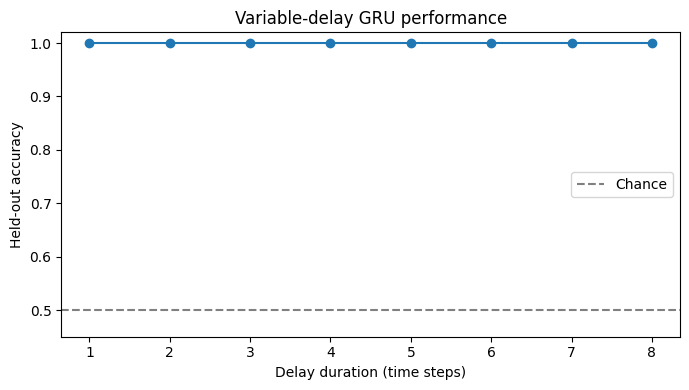

In [26]:
plt.figure(figsize=(7, 4))

plt.plot(
    accuracy_by_delay["delay_steps"],
    accuracy_by_delay["accuracy"],
    marker="o"
)

plt.axhline(
    0.5,
    color="gray",
    linestyle="--",
    label="Chance"
)

plt.xlabel("Delay duration (time steps)")
plt.ylabel("Held-out accuracy")
plt.ylim(0.45, 1.02)
plt.title("Variable-delay GRU performance")
plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/figures/variable_delay_accuracy.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [27]:
# Make a copy so the original test data remains unchanged
x_test_reference_removed_v = x_test_v.clone()

# Reference occurs at time step 0 in every trial
reference_time = 0

# Remove both the observed reference value and its presence flag
x_test_reference_removed_v[:, reference_time, 0] = 0.0
x_test_reference_removed_v[:, reference_time, 1] = 0.0

# Obtain probabilities using each trial's response-cue mask
ablation_probabilities_v = predict_masked_trials(
    model=variable_delay_model,
    x=x_test_reference_removed_v,
    response_mask=mask_test_v
)

ablation_predictions_v = (
    ablation_probabilities_v >= 0.5
).astype(int)

ablation_accuracy_v = (
    ablation_predictions_v == y_test_v.numpy().astype(int)
).mean()

print(f"Normal variable-delay accuracy: {delay_test_metrics['accuracy']:.3f}")
print(f"Reference-removed accuracy: {ablation_accuracy_v:.3f}")

Normal variable-delay accuracy: 1.000
Reference-removed accuracy: 0.494


In [28]:
x_test_probe_removed_v = x_test_v.clone()

# Probe time differs by trial, so use metadata rather than one fixed index
for trial_index, probe_time in enumerate(meta_test_v["probe_time"]):
    x_test_probe_removed_v[trial_index, probe_time, 0] = 0.0
    x_test_probe_removed_v[trial_index, probe_time, 1] = 0.0

probe_ablation_probabilities_v = predict_masked_trials(
    model=variable_delay_model,
    x=x_test_probe_removed_v,
    response_mask=mask_test_v
)

probe_ablation_predictions_v = (
    probe_ablation_probabilities_v >= 0.5
).astype(int)

probe_ablation_accuracy_v = (
    probe_ablation_predictions_v == y_test_v.numpy().astype(int)
).mean()

print(f"Probe-removed accuracy: {probe_ablation_accuracy_v:.3f}")

Probe-removed accuracy: 0.505


In [29]:
ablation_results = pd.DataFrame({
    "condition": [
        "intact_input",
        "reference_removed",
        "probe_removed"
    ],
    "accuracy": [
        delay_test_metrics["accuracy"],
        ablation_accuracy_v,
        probe_ablation_accuracy_v
    ]
})

print(ablation_results)

ablation_results.to_csv(
    "outputs/tables/variable_delay_ablation_results.csv",
    index=False
)

           condition  accuracy
0       intact_input  1.000000
1  reference_removed  0.494500
2      probe_removed  0.505167


In [30]:
def generate_noisy_graded_trials(
    n_trials,
    min_delay=1,
    max_delay=8,
    change_probability=0.5,
    change_magnitude_range=(0.02, 0.80),
    stimulus_noise=0.12,
    seed=None
):
    """
    Generate variable-delay trials with graded physical changes and
    sensory noise.

    Labels are based on the true trial condition:
        0 = same trial
        1 = change trial

    The RNN receives noisy observations, not true stimulus values.

    Returns:
        x:             Tensor, (trials, max_time, 3)
        y:             Tensor, (trials,)
        response_mask: Tensor, (trials, max_time)
        metadata:      DataFrame, one row per trial
    """
    rng = np.random.default_rng(seed)

    max_time = max_delay + 3

    x = np.zeros((n_trials, max_time, 3), dtype=np.float32)
    y = np.zeros(n_trials, dtype=np.float32)
    response_mask = np.zeros((n_trials, max_time), dtype=bool)

    rows = []

    for trial in range(n_trials):
        delay_steps = int(rng.integers(min_delay, max_delay + 1))

        reference = rng.uniform(0.0, 1.0)
        is_change = rng.random() < change_probability

        if is_change:
            change_magnitude = rng.uniform(
                change_magnitude_range[0],
                change_magnitude_range[1]
            )

            possible_directions = []

            if reference + change_magnitude <= 1.0:
                possible_directions.append(1.0)

            if reference - change_magnitude >= 0.0:
                possible_directions.append(-1.0)

            if len(possible_directions) == 0:
                change_magnitude = min(reference, 1.0 - reference)
                possible_directions = [1.0] if reference <= 0.5 else [-1.0]

            direction = rng.choice(possible_directions)
            probe = reference + direction * change_magnitude

        else:
            probe = reference
            change_magnitude = 0.0

        reference_observed = np.clip(
            reference + rng.normal(0.0, stimulus_noise),
            0.0,
            1.0
        )

        probe_observed = np.clip(
            probe + rng.normal(0.0, stimulus_noise),
            0.0,
            1.0
        )

        reference_time = 0
        probe_time = delay_steps + 1
        response_time = delay_steps + 2

        x[trial, reference_time] = [reference_observed, 1.0, 0.0]
        x[trial, probe_time] = [probe_observed, 1.0, 0.0]
        x[trial, response_time] = [0.0, 0.0, 1.0]

        response_mask[trial, response_time] = True
        y[trial] = float(is_change)

        rows.append({
            "trial": trial,
            "reference": reference,
            "probe": probe,
            "reference_observed": reference_observed,
            "probe_observed": probe_observed,
            "physical_change_magnitude": abs(probe - reference),
            "observed_change_magnitude": abs(
                probe_observed - reference_observed
            ),
            "is_change": int(is_change),
            "delay_steps": delay_steps,
            "reference_time": reference_time,
            "probe_time": probe_time,
            "response_time": response_time
        })

    return (
        torch.tensor(x, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(response_mask, dtype=torch.bool),
        pd.DataFrame(rows)
    )

In [31]:
x_noisy_demo, y_noisy_demo, mask_noisy_demo, meta_noisy_demo = (
    generate_noisy_graded_trials(
        n_trials=10,
        stimulus_noise=0.12,
        seed=42
    )
)

display(
    meta_noisy_demo[
        [
            "reference",
            "probe",
            "reference_observed",
            "probe_observed",
            "physical_change_magnitude",
            "observed_change_magnitude",
            "is_change",
            "delay_steps"
        ]
    ]
)

,reference,probe,reference_observed,probe_observed,physical_change_magnitude,observed_change_magnitude,is_change,delay_steps
0,0.438878,0.438878,0.551746,0.204754,0.000000,0.346992,0,1
1,0.975622,0.975622,0.937673,0.973606,0.000000,0.035933,0,7
2,0.370798,0.370798,0.378722,0.506067,0.000000,0.127345,0,7
3,0.443414,0.895990,0.328348,1.000000,0.452576,0.671652,1,4
4,0.758088,0.516175,0.739544,0.464776,0.241912,0.274768,1,3
5,0.194639,0.140472,0.246337,0.397469,0.054167,0.151132,1,6
6,0.967510,0.658551,1.000000,0.794028,0.308959,0.205972,1,2
7,0.475705,0.951410,0.564895,1.000000,0.475705,0.435105,1,4
8,0.832260,0.832260,0.846262,0.858502,0.000000,0.012240,0,2
9,0.139752,0.114010,0.174447,0.189765,0.025743,0.015318,1,2


In [32]:
noisy_task_parameters = {
    "min_delay": 1,
    "max_delay": 8,
    "change_probability": 0.5,
    "change_magnitude_range": (0.02, 0.80),
    "stimulus_noise": 0.12
}

x_train_n, y_train_n, mask_train_n, meta_train_n = (
    generate_noisy_graded_trials(
        n_trials=40_000,
        seed=21,
        **noisy_task_parameters
    )
)

x_val_n, y_val_n, mask_val_n, meta_val_n = (
    generate_noisy_graded_trials(
        n_trials=8_000,
        seed=22,
        **noisy_task_parameters
    )
)

x_test_n, y_test_n, mask_test_n, meta_test_n = (
    generate_noisy_graded_trials(
        n_trials=8_000,
        seed=23,
        **noisy_task_parameters
    )
)

train_loader_n = DataLoader(
    TensorDataset(x_train_n, y_train_n, mask_train_n),
    batch_size=128,
    shuffle=True
)

val_loader_n = DataLoader(
    TensorDataset(x_val_n, y_val_n, mask_val_n),
    batch_size=128,
    shuffle=False
)

test_loader_n = DataLoader(
    TensorDataset(x_test_n, y_test_n, mask_test_n),
    batch_size=128,
    shuffle=False
)

In [33]:
noisy_model = VariableDelayChangeDetectionGRU(
    input_size=3,
    hidden_size=32
).to(device)

loss_function = nn.BCEWithLogitsLoss()

optimizer_n = torch.optim.Adam(
    noisy_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

n_epochs = 50
noisy_history = []

best_noisy_val_loss = np.inf

for epoch in range(1, n_epochs + 1):
    train_metrics = run_masked_epoch(
        model=noisy_model,
        data_loader=train_loader_n,
        loss_function=loss_function,
        optimizer=optimizer_n
    )

    val_metrics = run_masked_epoch(
        model=noisy_model,
        data_loader=val_loader_n,
        loss_function=loss_function
    )

    noisy_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "validation_loss": val_metrics["loss"],
        "validation_accuracy": val_metrics["accuracy"]
    })

    if val_metrics["loss"] < best_noisy_val_loss:
        best_noisy_val_loss = val_metrics["loss"]

        torch.save(
            {
                "model_state_dict": noisy_model.state_dict(),
                "task_parameters": noisy_task_parameters,
                "hidden_size": 32,
                "epoch": epoch,
                "validation_loss": best_noisy_val_loss
            },
            "outputs/models/best_noisy_graded_gru.pt"
        )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"train loss={train_metrics['loss']:.4f}, "
            f"train accuracy={train_metrics['accuracy']:.3f} | "
            f"val loss={val_metrics['loss']:.4f}, "
            f"val accuracy={val_metrics['accuracy']:.3f}"
        )

noisy_history_df = pd.DataFrame(noisy_history)

noisy_history_df.to_csv(
    "outputs/tables/noisy_graded_training_history.csv",
    index=False
)

Epoch 01 | train loss=0.6933, train accuracy=0.501 | val loss=0.6931, val accuracy=0.507
Epoch 05 | train loss=0.6931, train accuracy=0.505 | val loss=0.6931, val accuracy=0.507
Epoch 10 | train loss=0.6931, train accuracy=0.506 | val loss=0.6931, val accuracy=0.507
Epoch 15 | train loss=0.6931, train accuracy=0.505 | val loss=0.6931, val accuracy=0.507
Epoch 20 | train loss=0.6931, train accuracy=0.506 | val loss=0.6931, val accuracy=0.507
Epoch 25 | train loss=0.6931, train accuracy=0.506 | val loss=0.6931, val accuracy=0.507
Epoch 30 | train loss=0.6931, train accuracy=0.506 | val loss=0.6931, val accuracy=0.507
Epoch 35 | train loss=0.6931, train accuracy=0.506 | val loss=0.6931, val accuracy=0.507
Epoch 40 | train loss=0.6931, train accuracy=0.507 | val loss=0.6931, val accuracy=0.507
Epoch 45 | train loss=0.6931, train accuracy=0.507 | val loss=0.6931, val accuracy=0.507
Epoch 50 | train loss=0.6931, train accuracy=0.507 | val loss=0.6931, val accuracy=0.507


In [34]:
x_batch, y_batch, mask_batch = next(iter(train_loader_n))

print("x batch shape:", x_batch.shape)
print("y batch shape:", y_batch.shape)
print("mask batch shape:", mask_batch.shape)

print("\nNumber of response-cue positions per trial:")
print(mask_batch.sum(dim=1).unique(return_counts=True))

with torch.no_grad():
    logits_over_time = noisy_model(x_batch.to(device))
    response_logits = logits_over_time[mask_batch.to(device)]

print("\nLogits over time shape:", logits_over_time.shape)
print("Selected response logits shape:", response_logits.shape)

print("\nLabel proportion of change trials:")
print(y_train_n.mean().item())

print("\nInitial/Current mean predicted probability:")
print(torch.sigmoid(response_logits).mean().item())

x batch shape: torch.Size([128, 11, 3])
y batch shape: torch.Size([128])
mask batch shape: torch.Size([128, 11])

Number of response-cue positions per trial:
(tensor([1]), tensor([128]))

Logits over time shape: torch.Size([128, 11])
Selected response logits shape: torch.Size([128])

Label proportion of change trials:
0.49342501163482666

Initial/Current mean predicted probability:
0.4940933287143707


In [35]:
SEED_MODERATE_NOISE = 42

random.seed(SEED_MODERATE_NOISE)
np.random.seed(SEED_MODERATE_NOISE)
torch.manual_seed(SEED_MODERATE_NOISE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_MODERATE_NOISE)

In [7]:
moderate_noise_model = VariableDelayChangeDetectionGRU(
    input_size=3,
    hidden_size=32
).to(device)

loss_function = nn.BCEWithLogitsLoss()

optimizer_m = torch.optim.Adam(
    moderate_noise_model.parameters(),
    lr=3e-3,
    weight_decay=1e-5
)

NameError: name 'VariableDelayChangeDetectionGRU' is not defined

In [37]:
moderate_noise_parameters = {
    "min_delay": 1,
    "max_delay": 8,
    "change_probability": 0.5,
    "change_magnitude_range": (0.02, 0.80),
    "stimulus_noise": 0.06
}

x_train_m, y_train_m, mask_train_m, meta_train_m = (
    generate_noisy_graded_trials(
        n_trials=40_000,
        seed=31,
        **moderate_noise_parameters
    )
)

x_val_m, y_val_m, mask_val_m, meta_val_m = (
    generate_noisy_graded_trials(
        n_trials=8_000,
        seed=32,
        **moderate_noise_parameters
    )
)

x_test_m, y_test_m, mask_test_m, meta_test_m = (
    generate_noisy_graded_trials(
        n_trials=8_000,
        seed=33,
        **moderate_noise_parameters
    )
)

train_loader_m = DataLoader(
    TensorDataset(x_train_m, y_train_m, mask_train_m),
    batch_size=128,
    shuffle=True
)

val_loader_m = DataLoader(
    TensorDataset(x_val_m, y_val_m, mask_val_m),
    batch_size=128,
    shuffle=False
)

test_loader_m = DataLoader(
    TensorDataset(x_test_m, y_test_m, mask_test_m),
    batch_size=128,
    shuffle=False
)

In [38]:
torch.manual_seed(42)

moderate_noise_model = VariableDelayChangeDetectionGRU(
    input_size=3,
    hidden_size=32
).to(device)

loss_function = nn.BCEWithLogitsLoss()

optimizer_m = torch.optim.Adam(
    moderate_noise_model.parameters(),
    lr=3e-3,
    weight_decay=1e-5
)

In [39]:
n_epochs = 80
moderate_history = []

best_moderate_val_loss = np.inf

for epoch in range(1, n_epochs + 1):
    train_metrics = run_masked_epoch(
        model=moderate_noise_model,
        data_loader=train_loader_m,
        loss_function=loss_function,
        optimizer=optimizer_m
    )

    val_metrics = run_masked_epoch(
        model=moderate_noise_model,
        data_loader=val_loader_m,
        loss_function=loss_function
    )

    moderate_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "validation_loss": val_metrics["loss"],
        "validation_accuracy": val_metrics["accuracy"]
    })

    if val_metrics["loss"] < best_moderate_val_loss:
        best_moderate_val_loss = val_metrics["loss"]

        torch.save(
            {
                "model_state_dict": moderate_noise_model.state_dict(),
                "task_parameters": moderate_noise_parameters,
                "hidden_size": 32,
                "epoch": epoch,
                "validation_loss": best_moderate_val_loss
            },
            "outputs/models/best_moderate_noise_gru.pt"
        )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"train loss={train_metrics['loss']:.4f}, "
            f"train accuracy={train_metrics['accuracy']:.3f} | "
            f"val loss={val_metrics['loss']:.4f}, "
            f"val accuracy={val_metrics['accuracy']:.3f}"
        )

moderate_history_df = pd.DataFrame(moderate_history)

moderate_history_df.to_csv(
    "outputs/tables/moderate_noise_training_history.csv",
    index=False
)

Epoch 01 | train loss=0.6935, train accuracy=0.499 | val loss=0.6933, val accuracy=0.504
Epoch 05 | train loss=0.6932, train accuracy=0.501 | val loss=0.6933, val accuracy=0.507
Epoch 10 | train loss=0.6932, train accuracy=0.504 | val loss=0.6932, val accuracy=0.497
Epoch 15 | train loss=0.3014, train accuracy=0.879 | val loss=0.3128, val accuracy=0.871
Epoch 20 | train loss=0.2972, train accuracy=0.880 | val loss=0.3022, val accuracy=0.878
Epoch 25 | train loss=0.2972, train accuracy=0.879 | val loss=0.2963, val accuracy=0.882
Epoch 30 | train loss=0.2957, train accuracy=0.881 | val loss=0.2958, val accuracy=0.881
Epoch 35 | train loss=0.2954, train accuracy=0.880 | val loss=0.2965, val accuracy=0.882
Epoch 40 | train loss=0.2952, train accuracy=0.881 | val loss=0.2992, val accuracy=0.878
Epoch 45 | train loss=0.2948, train accuracy=0.880 | val loss=0.2997, val accuracy=0.878
Epoch 50 | train loss=0.2946, train accuracy=0.881 | val loss=0.2973, val accuracy=0.881
Epoch 55 | train loss

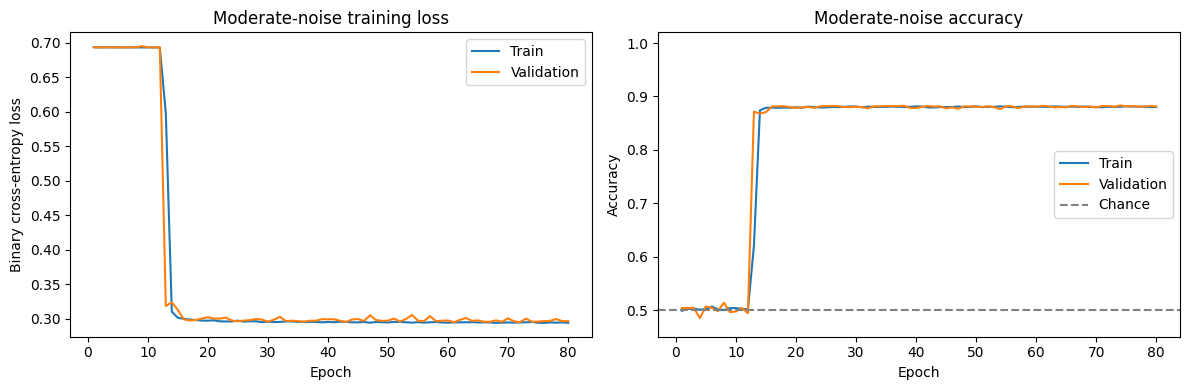

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    moderate_history_df["epoch"],
    moderate_history_df["train_loss"],
    label="Train"
)

axes[0].plot(
    moderate_history_df["epoch"],
    moderate_history_df["validation_loss"],
    label="Validation"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy loss")
axes[0].set_title("Moderate-noise training loss")
axes[0].legend()

axes[1].plot(
    moderate_history_df["epoch"],
    moderate_history_df["train_accuracy"],
    label="Train"
)

axes[1].plot(
    moderate_history_df["epoch"],
    moderate_history_df["validation_accuracy"],
    label="Validation"
)

axes[1].axhline(
    0.5,
    color="gray",
    linestyle="--",
    label="Chance"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.45, 1.02)
axes[1].set_title("Moderate-noise accuracy")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "outputs/figures/moderate_noise_learning_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [41]:
checkpoint_m = torch.load(
    "outputs/models/best_moderate_noise_gru.pt",
    map_location=device
)

moderate_noise_model.load_state_dict(
    checkpoint_m["model_state_dict"]
)

moderate_noise_model.eval()

moderate_test_metrics = run_masked_epoch(
    model=moderate_noise_model,
    data_loader=test_loader_m,
    loss_function=loss_function
)

print(f"Best epoch: {checkpoint_m['epoch']}")
print(f"Test loss: {moderate_test_metrics['loss']:.4f}")
print(f"Test accuracy: {moderate_test_metrics['accuracy']:.3f}")

Best epoch: 61
Test loss: 0.3009
Test accuracy: 0.875


In [6]:
moderate_probabilities = predict_masked_trials(
    model=moderate_noise_model,
    x=x_test_m,
    response_mask=mask_test_m
)

moderate_results = meta_test_m.copy()

moderate_results["rnn_change_probability"] = moderate_probabilities

moderate_results["rnn_response_change"] = (
    moderate_results["rnn_change_probability"] >= 0.5
).astype(int)

moderate_results["correct"] = (
    moderate_results["rnn_response_change"] ==
    moderate_results["is_change"]
).astype(int)

moderate_results.to_csv(
    "outputs/tables/moderate_noise_rnn_trials.csv",
    index=False
)

display(moderate_results.head())

NameError: name 'moderate_noise_model' is not defined

In [43]:
def classify_signal_detection_outcome(row):
    if row["is_change"] == 1 and row["rnn_response_change"] == 1:
        return "hit"

    if row["is_change"] == 1 and row["rnn_response_change"] == 0:
        return "miss"

    if row["is_change"] == 0 and row["rnn_response_change"] == 1:
        return "false_alarm"

    return "correct_rejection"

In [44]:
moderate_results["outcome"] = moderate_results.apply(
    classify_signal_detection_outcome,
    axis=1
)

outcome_counts_m = (
    moderate_results["outcome"]
    .value_counts()
    .reindex(
        ["hit", "miss", "false_alarm", "correct_rejection"],
        fill_value=0
    )
)

outcome_rates_m = pd.Series({
    "hit_rate": (
        (moderate_results["outcome"] == "hit").sum() /
        (moderate_results["is_change"] == 1).sum()
    ),
    "miss_rate": (
        (moderate_results["outcome"] == "miss").sum() /
        (moderate_results["is_change"] == 1).sum()
    ),
    "false_alarm_rate": (
        (moderate_results["outcome"] == "false_alarm").sum() /
        (moderate_results["is_change"] == 0).sum()
    ),
    "correct_rejection_rate": (
        (moderate_results["outcome"] == "correct_rejection").sum() /
        (moderate_results["is_change"] == 0).sum()
    )
})

print("Outcome counts")
print(outcome_counts_m)

print("\nOutcome rates")
print(outcome_rates_m)

Outcome counts
outcome
hit                  3177
miss                  802
false_alarm           197
correct_rejection    3824
Name: count, dtype: int64

Outcome rates
hit_rate                  0.798442
miss_rate                 0.201558
false_alarm_rate          0.048993
correct_rejection_rate    0.951007
dtype: float64


In [45]:
change_trials_m = moderate_results[
    moderate_results["is_change"] == 1
].copy()

bin_edges = [0.00, 0.05, 0.10, 0.20, 0.40, 0.60, 0.81]

change_trials_m["change_bin"] = pd.cut(
    change_trials_m["physical_change_magnitude"],
    bins=bin_edges,
    include_lowest=True
)

psychometric_m = (
    change_trials_m
    .groupby("change_bin", observed=False)
    .agg(
        n_trials=("trial", "size"),
        mean_change_magnitude=(
            "physical_change_magnitude",
            "mean"
        ),
        p_response_change=(
            "rnn_response_change",
            "mean"
        ),
        mean_change_probability=(
            "rnn_change_probability",
            "mean"
        ),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

print(psychometric_m)

       change_bin  n_trials  mean_change_magnitude  p_response_change  \
0  (-0.001, 0.05]       151               0.034203           0.086093   
1     (0.05, 0.1]       274               0.076144           0.116788   
2      (0.1, 0.2]       535               0.150142           0.422430   
3      (0.2, 0.4]      1188               0.303289           0.904882   
4      (0.4, 0.6]      1234               0.489589           1.000000   
5     (0.6, 0.81]       597               0.687132           1.000000   

   mean_change_probability  accuracy  
0                 0.224304  0.086093  
1                 0.264461  0.116788  
2                 0.472631  0.422430  
3                 0.882373  0.904882  
4                 0.997821  1.000000  
5                 0.999920  1.000000  


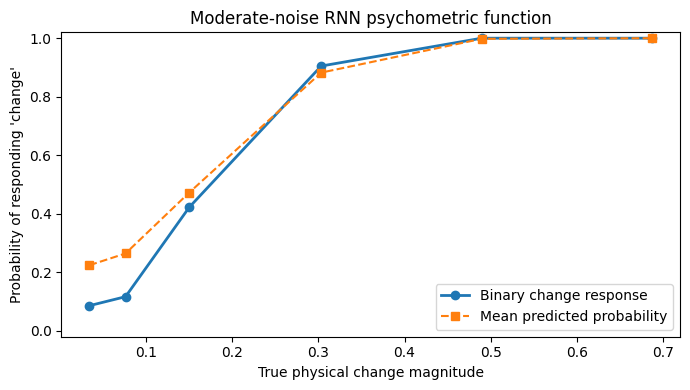

In [46]:
plt.figure(figsize=(7, 4))

plt.plot(
    psychometric_m["mean_change_magnitude"],
    psychometric_m["p_response_change"],
    marker="o",
    linewidth=2,
    label="Binary change response"
)

plt.plot(
    psychometric_m["mean_change_magnitude"],
    psychometric_m["mean_change_probability"],
    marker="s",
    linestyle="--",
    label="Mean predicted probability"
)

plt.xlabel("True physical change magnitude")
plt.ylabel("Probability of responding 'change'")
plt.ylim(-0.02, 1.02)
plt.title("Moderate-noise RNN psychometric function")
plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/figures/moderate_noise_psychometric_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

psychometric_m.to_csv(
    "outputs/tables/moderate_noise_psychometric_curve.csv",
    index=False
)

In [47]:
same_trials_m = moderate_results[
    moderate_results["is_change"] == 0
]

false_alarm_rate_m = same_trials_m[
    "rnn_response_change"
].mean()

mean_probability_same_m = same_trials_m[
    "rnn_change_probability"
].mean()

print(f"Same trials: {len(same_trials_m)}")
print(f"False-alarm rate at Δ = 0: {false_alarm_rate_m:.3f}")
print(
    "Mean predicted change probability at Δ = 0: "
    f"{mean_probability_same_m:.3f}"
)

Same trials: 4021
False-alarm rate at Δ = 0: 0.049
Mean predicted change probability at Δ = 0: 0.192


In [48]:
@torch.no_grad()
def get_masked_hidden_trajectories(model, x):
    """
    Extract trial-by-time-by-unit GRU hidden-state trajectories.

    Returns
    -------
    probabilities : numpy.ndarray
        Shape: (n_trials,)

    hidden_trajectory : numpy.ndarray
        Shape: (n_trials, time_steps, hidden_units)
    """
    model.eval()

    logits_over_time, hidden_trajectory = model(
        x.to(device),
        return_hidden_trajectory=True
    )

    return (
        torch.sigmoid(logits_over_time).cpu().numpy(),
        hidden_trajectory.cpu().numpy()
    )

In [49]:
all_time_probabilities, hidden_states_m = get_masked_hidden_trajectories(
    model=moderate_noise_model,
    x=x_test_m
)

print("Hidden-state shape:", hidden_states_m.shape)

Hidden-state shape: (8000, 11, 32)


In [50]:
def extract_task_phase_states(hidden_states, metadata):
    """
    Align hidden states to meaningful trial phases.

    Returns
    -------
    phase_states : dict
        Each value has shape (n_trials, hidden_units).
    """
    n_trials = len(metadata)
    trial_indices = np.arange(n_trials)

    probe_times = metadata["probe_time"].to_numpy()
    response_times = metadata["response_time"].to_numpy()

    phase_states = {
        "reference": hidden_states[:, 0, :],
        "early_delay": hidden_states[:, 1, :],
        "late_delay": hidden_states[
            trial_indices,
            probe_times - 1,
            :
        ],
        "probe": hidden_states[
            trial_indices,
            probe_times,
            :
        ],
        "response": hidden_states[
            trial_indices,
            response_times,
            :
        ]
    }

    return phase_states

In [51]:
phase_states_m = extract_task_phase_states(
    hidden_states=hidden_states_m,
    metadata=meta_test_m
)

for phase_name, states in phase_states_m.items():
    print(f"{phase_name}: {states.shape}")

reference: (8000, 32)
early_delay: (8000, 32)
late_delay: (8000, 32)
probe: (8000, 32)
response: (8000, 32)


In [52]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [53]:
reference_values_m = meta_test_m["reference"].to_numpy()

train_indices, test_indices = train_test_split(
    np.arange(len(reference_values_m)),
    test_size=0.25,
    random_state=42
)

reference_decoding_rows = []

for phase_name, states in phase_states_m.items():
    decoder = Ridge(alpha=1.0)

    decoder.fit(
        states[train_indices],
        reference_values_m[train_indices]
    )

    predicted_reference = decoder.predict(
        states[test_indices]
    )

    decoding_r2 = r2_score(
        reference_values_m[test_indices],
        predicted_reference
    )

    reference_decoding_rows.append({
        "phase": phase_name,
        "reference_decoding_r2": decoding_r2
    })

reference_decoding_m = pd.DataFrame(reference_decoding_rows)

print(reference_decoding_m)

reference_decoding_m.to_csv(
    "outputs/tables/moderate_noise_reference_decoding.csv",
    index=False
)

         phase  reference_decoding_r2
0    reference               0.964786
1  early_delay               0.964934
2   late_delay               0.964439
3        probe               0.965767
4     response               0.966627


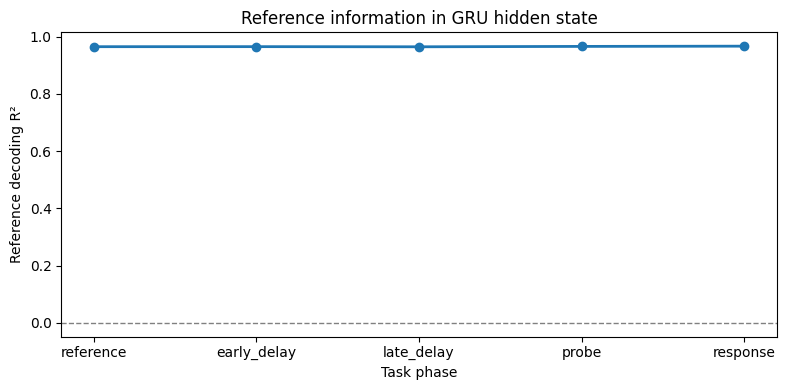

In [54]:
phase_order = [
    "reference",
    "early_delay",
    "late_delay",
    "probe",
    "response"
]

reference_decoding_m["phase"] = pd.Categorical(
    reference_decoding_m["phase"],
    categories=phase_order,
    ordered=True
)

reference_decoding_m = reference_decoding_m.sort_values("phase")

plt.figure(figsize=(8, 4))

plt.plot(
    reference_decoding_m["phase"],
    reference_decoding_m["reference_decoding_r2"],
    marker="o",
    linewidth=2
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Task phase")
plt.ylabel("Reference decoding R²")
plt.title("Reference information in GRU hidden state")

plt.tight_layout()

plt.savefig(
    "outputs/figures/moderate_noise_reference_decoding.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [55]:
moderate_results["outcome"] = moderate_results.apply(
    classify_signal_detection_outcome,
    axis=1
)

print(moderate_results["outcome"].value_counts())

outcome
correct_rejection    3824
hit                  3177
miss                  802
false_alarm           197
Name: count, dtype: int64


In [56]:
from sklearn.decomposition import PCA

In [57]:
phase_matrix_m = np.concatenate(
    [phase_states_m[phase] for phase in phase_order],
    axis=0
)

pca = PCA(n_components=2)

pca.fit(phase_matrix_m)

print(
    "Variance explained by PC1 and PC2:",
    pca.explained_variance_ratio_
)

Variance explained by PC1 and PC2: [0.4291253  0.19601583]


In [58]:
phase_coordinates_m = {}

for phase in phase_order:
    phase_coordinates_m[phase] = pca.transform(
        phase_states_m[phase]
    )

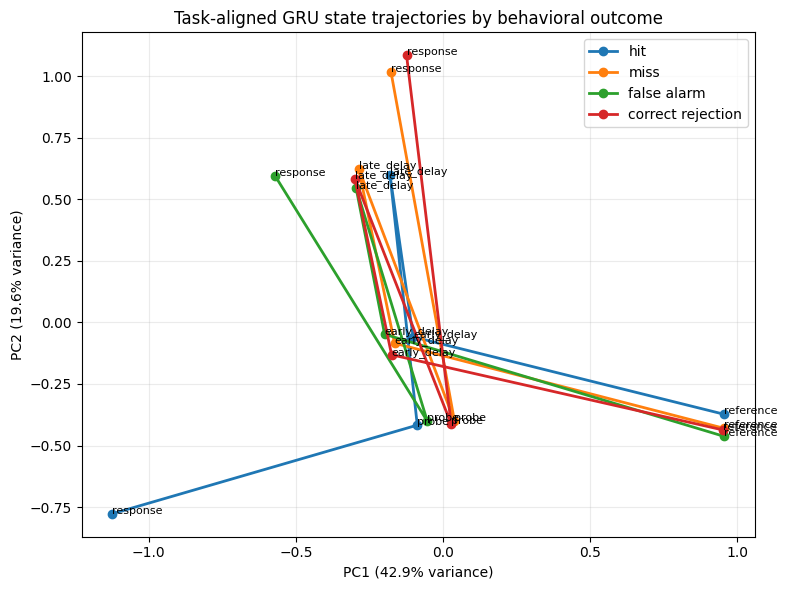

In [59]:
outcome_colors = {
    "hit": "#1f77b4",
    "miss": "#d62728",
    "false_alarm": "#ff7f0e",
    "correct_rejection": "#2ca02c"
}

plt.figure(figsize=(8, 6))

for outcome_name in [
    "hit",
    "miss",
    "false_alarm",
    "correct_rejection"
]:
    trial_mask = (
        moderate_results["outcome"].to_numpy() == outcome_name
    )

    mean_trajectory = np.vstack([
        phase_coordinates_m[phase][trial_mask].mean(axis=0)
        for phase in phase_order
    ])

    plt.plot(
        mean_trajectory[:, 0],
        mean_trajectory[:, 1],
        marker="o",
        linewidth=2,
        label=outcome_name.replace("_", " ")
    )

    for phase_index, phase_name in enumerate(phase_order):
        plt.annotate(
            phase_name,
            (
                mean_trajectory[phase_index, 0],
                mean_trajectory[phase_index, 1]
            ),
            fontsize=8
        )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("Task-aligned GRU state trajectories by behavioral outcome")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "outputs/figures/moderate_noise_outcome_trajectories.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [60]:
trajectory_rows = []

for phase_name in phase_order:
    coordinates = phase_coordinates_m[phase_name]

    phase_table = moderate_results[
        [
            "trial",
            "is_change",
            "physical_change_magnitude",
            "delay_steps",
            "rnn_change_probability",
            "rnn_response_change",
            "correct",
            "outcome"
        ]
    ].copy()

    phase_table["phase"] = phase_name
    phase_table["pc1"] = coordinates[:, 0]
    phase_table["pc2"] = coordinates[:, 1]

    trajectory_rows.append(phase_table)

rnn_trajectory_table = pd.concat(
    trajectory_rows,
    ignore_index=True
)

rnn_trajectory_table.to_csv(
    "outputs/tables/moderate_noise_rnn_pca_trajectories.csv",
    index=False
)

print(rnn_trajectory_table.head())

   trial  is_change  physical_change_magnitude  delay_steps  \
0      0          0                   0.000000            8   
1      1          0                   0.000000            4   
2      2          1                   0.108076            6   
3      3          1                   0.430416            8   
4      4          0                   0.000000            7   

   rnn_change_probability  rnn_response_change  correct            outcome  \
0                0.222581                    0        1  correct_rejection   
1                0.146724                    0        1  correct_rejection   
2                0.143829                    0        0               miss   
3                0.999429                    1        1                hit   
4                0.212268                    0        1  correct_rejection   

       phase       pc1       pc2  
0  reference  0.973781 -0.661684  
1  reference  0.982568 -0.060635  
2  reference  0.954716  0.754131  
3  reference

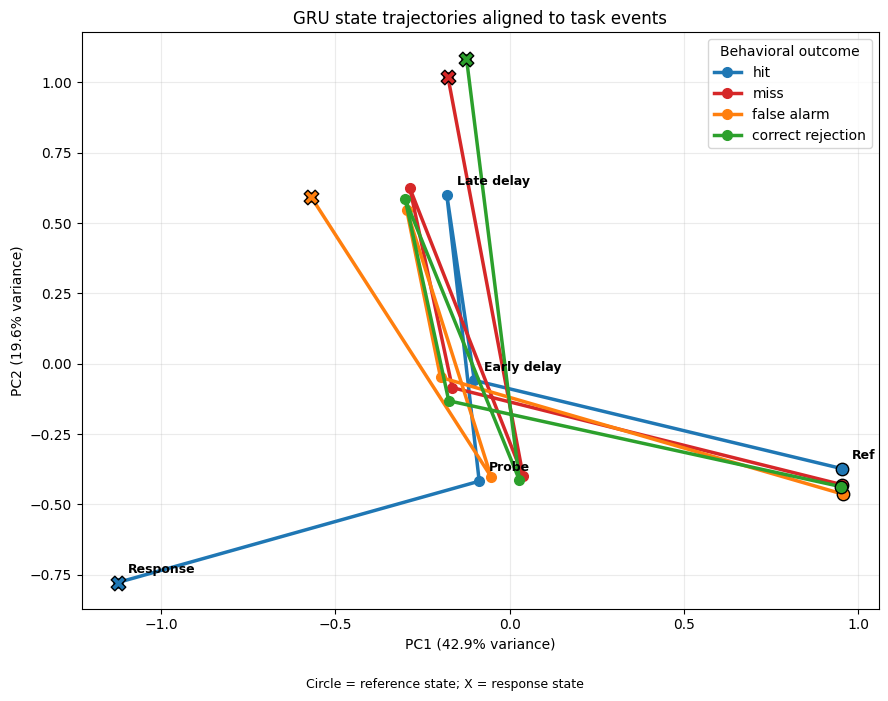

In [61]:
phase_short_labels = {
    "reference": "Ref",
    "early_delay": "Early delay",
    "late_delay": "Late delay",
    "probe": "Probe",
    "response": "Response"
}

outcome_colors = {
    "hit": "#1f77b4",
    "miss": "#d62728",
    "false_alarm": "#ff7f0e",
    "correct_rejection": "#2ca02c"
}

plt.figure(figsize=(9, 7))

for outcome_name in [
    "hit",
    "miss",
    "false_alarm",
    "correct_rejection"
]:
    trial_mask = (
        moderate_results["outcome"].to_numpy() == outcome_name
    )

    mean_trajectory = np.vstack([
        phase_coordinates_m[phase][trial_mask].mean(axis=0)
        for phase in phase_order
    ])

    plt.plot(
        mean_trajectory[:, 0],
        mean_trajectory[:, 1],
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=outcome_colors[outcome_name],
        label=outcome_name.replace("_", " ")
    )

    plt.scatter(
        mean_trajectory[0, 0],
        mean_trajectory[0, 1],
        s=80,
        color=outcome_colors[outcome_name],
        edgecolor="black",
        zorder=3
    )

    plt.scatter(
        mean_trajectory[-1, 0],
        mean_trajectory[-1, 1],
        s=110,
        color=outcome_colors[outcome_name],
        marker="X",
        edgecolor="black",
        zorder=3
    )

# Label phases only once, using hit trajectory as a reference
hit_mask = moderate_results["outcome"].to_numpy() == "hit"

hit_trajectory = np.vstack([
    phase_coordinates_m[phase][hit_mask].mean(axis=0)
    for phase in phase_order
])

for phase_index, phase_name in enumerate(phase_order):
    plt.annotate(
        phase_short_labels[phase_name],
        (
            hit_trajectory[phase_index, 0],
            hit_trajectory[phase_index, 1]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("GRU state trajectories aligned to task events")
plt.legend(title="Behavioral outcome")
plt.grid(alpha=0.25)

plt.figtext(
    0.5,
    0.01,
    "Circle = reference state; X = response state",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig(
    "outputs/figures/moderate_noise_outcome_trajectories_clean.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [62]:
def mean_state_for_outcome(hidden_states, outcomes, outcome_name):
    trial_mask = outcomes == outcome_name
    return hidden_states[trial_mask].mean(axis=0)


outcomes_array = moderate_results["outcome"].to_numpy()

trajectory_distance_rows = []

comparisons = [
    ("hit", "miss", "True change: correct vs incorrect"),
    ("false_alarm", "correct_rejection", "Same: incorrect vs correct"),
    ("hit", "false_alarm", "Change response: true vs false"),
    ("miss", "correct_rejection", "Same response: change vs same")
]

for phase_name in phase_order:
    states = phase_states_m[phase_name]

    for outcome_a, outcome_b, comparison_name in comparisons:
        mean_a = mean_state_for_outcome(
            states,
            outcomes_array,
            outcome_a
        )

        mean_b = mean_state_for_outcome(
            states,
            outcomes_array,
            outcome_b
        )

        distance = np.linalg.norm(mean_a - mean_b)

        trajectory_distance_rows.append({
            "phase": phase_name,
            "comparison": comparison_name,
            "euclidean_distance": distance
        })

trajectory_distances = pd.DataFrame(trajectory_distance_rows)

print(trajectory_distances)

trajectory_distances.to_csv(
    "outputs/tables/moderate_noise_outcome_state_distances.csv",
    index=False
)

          phase                         comparison  euclidean_distance
0     reference  True change: correct vs incorrect            0.066071
1     reference         Same: incorrect vs correct            0.029940
2     reference     Change response: true vs false            0.103385
3     reference      Same response: change vs same            0.012376
4   early_delay  True change: correct vs incorrect            0.079451
5   early_delay         Same: incorrect vs correct            0.122121
6   early_delay     Change response: true vs false            0.133204
7   early_delay      Same response: change vs same            0.058292
8    late_delay  True change: correct vs incorrect            0.114439
9    late_delay         Same: incorrect vs correct            0.144938
10   late_delay     Change response: true vs false            0.170074
11   late_delay      Same response: change vs same            0.063509
12        probe  True change: correct vs incorrect            0.445670
13    

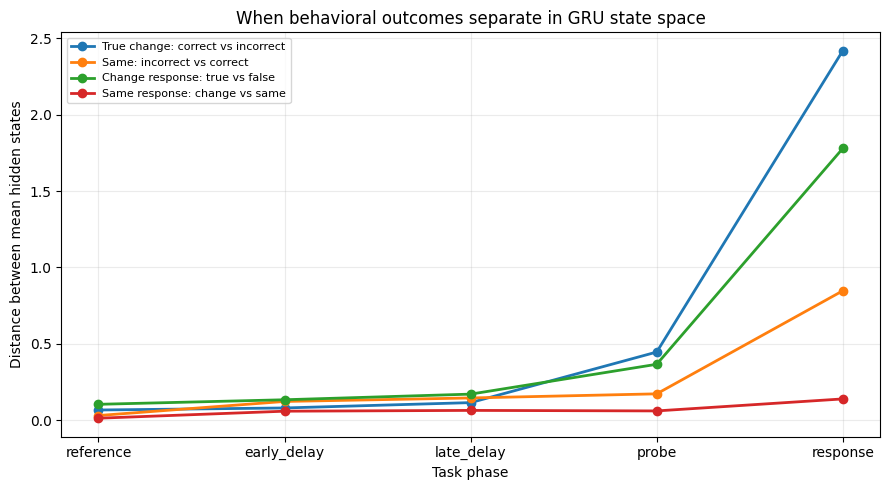

In [63]:
plt.figure(figsize=(9, 5))

for comparison_name in trajectory_distances["comparison"].unique():
    subset = trajectory_distances[
        trajectory_distances["comparison"] == comparison_name
    ].copy()

    subset["phase"] = pd.Categorical(
        subset["phase"],
        categories=phase_order,
        ordered=True
    )

    subset = subset.sort_values("phase")

    plt.plot(
        subset["phase"],
        subset["euclidean_distance"],
        marker="o",
        linewidth=2,
        label=comparison_name
    )

plt.xlabel("Task phase")
plt.ylabel("Distance between mean hidden states")
plt.title("When behavioral outcomes separate in GRU state space")
plt.legend(fontsize=8)
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "outputs/figures/moderate_noise_outcome_separation.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [3]:
from scipy.stats import norm
import pandas as pd

rnn_signal_trials = moderate_results[
    moderate_results["is_change"] == 1
]

rnn_noise_trials = moderate_results[
    moderate_results["is_change"] == 0
]

rnn_hits = int(
    rnn_signal_trials["rnn_response_change"].sum()
)

rnn_false_alarms = int(
    rnn_noise_trials["rnn_response_change"].sum()
)

rnn_n_signal = len(rnn_signal_trials)
rnn_n_noise = len(rnn_noise_trials)

rnn_hit_rate_corrected = (
    (rnn_hits + 0.5) /
    (rnn_n_signal + 1)
)

rnn_false_alarm_rate_corrected = (
    (rnn_false_alarms + 0.5) /
    (rnn_n_noise + 1)
)

rnn_d_prime = (
    norm.ppf(rnn_hit_rate_corrected) -
    norm.ppf(rnn_false_alarm_rate_corrected)
)

rnn_criterion = -0.5 * (
    norm.ppf(rnn_hit_rate_corrected) +
    norm.ppf(rnn_false_alarm_rate_corrected)
)

rnn_behavior_summary = pd.DataFrame([{
    "model": "moderate_noise_gru",
    "n_change_trials": rnn_n_signal,
    "n_same_trials": rnn_n_noise,
    "hit_rate_raw": rnn_hits / rnn_n_signal,
    "false_alarm_rate_raw": rnn_false_alarms / rnn_n_noise,
    "hit_rate_corrected": rnn_hit_rate_corrected,
    "false_alarm_rate_corrected": rnn_false_alarm_rate_corrected,
    "d_prime": rnn_d_prime,
    "criterion": rnn_criterion
}])

display(rnn_behavior_summary)

NameError: name 'moderate_results' is not defined